In [2]:
import wfdb
# path = "/content/mit-bih-arrhythmia-database-1.0.0/100"
path="C:\\Users\\PC\\Desktop\\MIT_2\\mit-bih-arrhythmia-database-1.0.0\\mit-bih-arrhythmia-database-1.0.0\\100"
record = wfdb.rdrecord(path)
annotation = wfdb.rdann(path, 'atr')

signal = record.p_signal

print("Shape:", signal.shape)
print("First labels:", annotation.symbol[:10])

Shape: (650000, 2)
First labels: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


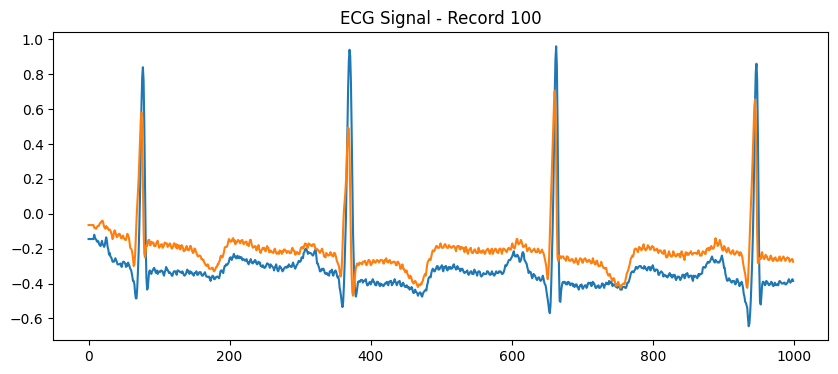

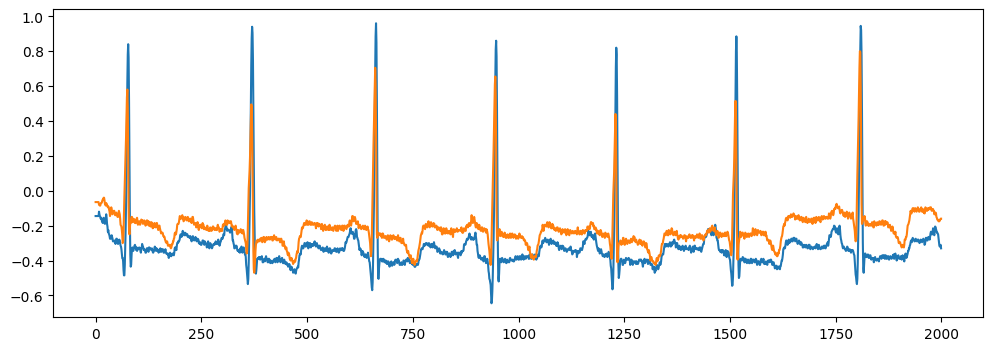

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(signal[:1000])
plt.title("ECG Signal - Record 100")
plt.show()

start = 0
end = 2000

plt.figure(figsize=(12,4))
plt.plot(signal[start:end], label="ECG")


C:\Users\PC\AppData\Local\Temp\ipykernel_9488\3871156964.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


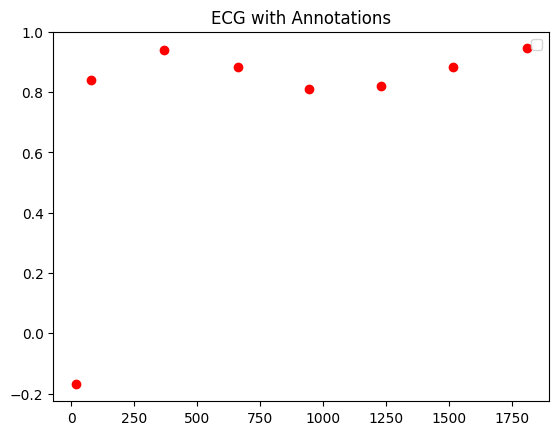

In [5]:

for i in range(len(annotation.sample)):
    if start <= annotation.sample[i] < end:
        plt.plot(annotation.sample[i]-start,
                 signal[annotation.sample[i], 0],
                 'ro')

plt.legend()
plt.title("ECG with Annotations")
plt.show()

In [6]:
import wfdb
import numpy as np
import pandas as pd

# Correct full dataset
records = [str(i) for i in range(100, 125)] + [str(i) for i in range(200, 235)]

# base_path = "/content/physionet.org/files/mitdb/1.0.0/"
base_path = "C:/Users/PC/Desktop/MIT_2/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0/"

# base_path = "/content/mit-bih-arrhythmia-database-1.0.0/"
X = []
y = []
hr_list = []  

window_before = 100
window_after = 200

for rec in records:
    try:
        path = base_path + rec

        record = wfdb.rdrecord(path)
        annotation = wfdb.rdann(path, 'atr')

        signal = record.p_signal[:,0]

        for i in range(1, len(annotation.sample)):   # 👈 start from 1
            idx = annotation.sample[i]
            label = annotation.symbol[i]

            if idx - window_before >= 0 and idx + window_after < len(signal):
                beat = signal[idx - window_before : idx + window_after]

                # Label
                if label == 'N':
                    y.append(0)
                else:
                    y.append(1)

                X.append(beat)

                # ✅ HR FROM ECG (REAL)
                rr = (annotation.sample[i] - annotation.sample[i-1]) / record.fs
                hr = 60 / rr
                hr_list.append(hr)

        print(f"Loaded record {rec}")

    except Exception as e:
        print(f"Skipping {rec}: {e}")

X = np.array(X)
y = np.array(y)
hr = np.array(hr_list)

# Remove unrealistic values
hr[(hr < 30) | (hr > 200)] = np.nan

# Fill missing values (simple interpolation)
hr = pd.Series(hr).interpolate().fillna(method='bfill').fillna(method='ffill').values

min_len = min(len(X), len(hr))
X = X[:min_len]
y = y[:min_len]
hr = hr[:min_len]

print("Final Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Loaded record 100
Loaded record 101
Loaded record 102
Loaded record 103
Loaded record 104
Loaded record 105
Loaded record 106
Loaded record 107
Loaded record 108
Loaded record 109
Skipping 110: [Errno 2] No such file or directory: 'C:/Users/PC/Desktop/MIT_2/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0/110.hea'
Loaded record 111
Loaded record 112
Loaded record 113
Loaded record 114
Loaded record 115
Loaded record 116
Loaded record 117
Loaded record 118
Loaded record 119
Skipping 120: [Errno 2] No such file or directory: 'C:/Users/PC/Desktop/MIT_2/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0/120.hea'
Loaded record 121
Loaded record 122
Loaded record 123
Loaded record 124
Loaded record 200
Loaded record 201
Loaded record 202
Loaded record 203
Skipping 204: [Errno 2] No such file or directory: 'C:/Users/PC/Desktop/MIT_2/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0/204.hea'
Loaded record 205
Skipping 206: [Errno 2] No such

C:\Users\PC\AppData\Local\Temp\ipykernel_9488\303284524.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hr = pd.Series(hr).interpolate().fillna(method='bfill').fillna(method='ffill').values


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test, hr_train, hr_test = train_test_split(
    X, y, hr, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9830741892492225


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     15063
           1       0.99      0.96      0.97      7447

    accuracy                           0.98     22510
   macro avg       0.98      0.98      0.98     22510
weighted avg       0.98      0.98      0.98     22510



In [9]:
X = X.reshape(X.shape[0], X.shape[1], 1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
cnn_binary_model  = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

In [11]:

cnn_binary_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_binary_model.summary()

# ==============================
# TRAINING
# ==============================

history = cnn_binary_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,   # good for GPU
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 296, 32)           192       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 148, 32)          0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 144, 64)           10304     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 72, 64)           0         
 1D)                                                             
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 64)                2

In [ ]:
loss, acc = cnn_binary_model.evaluate(X_test, y_test)
print("CNN Accuracy:", acc)

# Pick a sample from X_test (change index to test different ones)
ecg_sample = X_test[0]
ecg_pred = (cnn_binary_model.predict(ecg_sample.reshape(1, 300, 1)) > 0.5).astype(int)[0][0]
print("Predicted class:", ecg_pred, "| True class:", y_test[0])

704/704 [==============================] - 2s 2ms/step - loss: 0.0425 - accuracy: 0.9893
CNN Accuracy: 0.98929363489151
1/1 [==============================] - 0s 92ms/step
Predicted class: 0 | True class: 0


704/704 [==============================] - 1s 903us/step


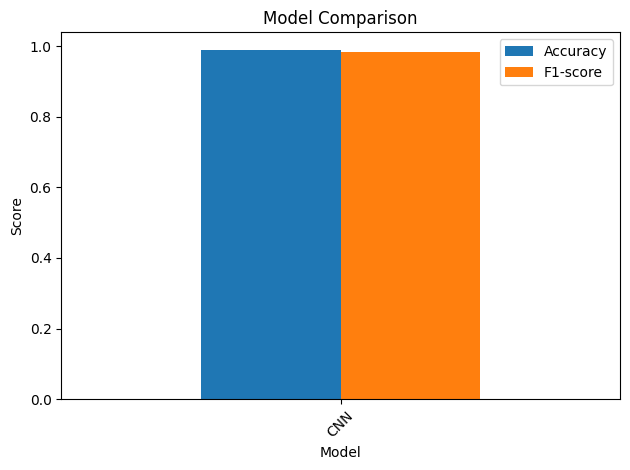

In [15]:
import tensorflow as tf

loss, acc = cnn_binary_model.evaluate(X_test, y_test, verbose=0)

y_probs = cnn_binary_model.predict(X_test)
y_pred = (y_probs > 0.5).astype(int)

# ==============================
# METRICS (TensorFlow only)
# ==============================

precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()

precision.update_state(y_test, y_pred)
recall.update_state(y_test, y_pred)

precision_val = precision.result().numpy()
recall_val = recall.result().numpy()

f1_score = 2 * (precision_val * recall_val) / (precision_val + recall_val + 1e-8)

# ==============================
# RESULTS TABLE
# ==============================

results_df = pd.DataFrame({
    "Model": ["CNN"],
    "Accuracy": [acc],
    "F1-score": [f1_score]
})

# ==============================
# PLOT (same as your code)
# ==============================

import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "F1-score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.xlabel("Model")

plt.tight_layout()
plt.show()

In [16]:

print("Predicted classes:", np.unique(y_pred, return_counts=True))
print("True classes:", np.unique(y_test, return_counts=True))

Predicted classes: (array([0, 1]), array([15208,  7302], dtype=int64))
True classes: (array([0, 1]), array([15063,  7447], dtype=int64))


# ECG Pipeline (BIDMC + VitalDB)
Local execution version (no kagglehub, Colab-free)

Includes:
- BIDMC ECG loading (wfdb)
- VitalDB parquet loading
- Basic preprocessing
- LSTM-ready dataset

In [17]:
import os
import numpy as np
import pandas as pd
import wfdb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# import torch
# import torch.nn as nn

In [18]:
# SET YOUR PATHS
BIDMC_PATH = r"C:\Users\PC\Desktop\MIT_2\bidmc\content\drive\MyDrive\physionet"
VITALDB_PATH = r"C:\Users\PC\Desktop\MIT_2\my_folder\content\vitaldb-preprocessing\VitalDB_Preprocessing\featured_batches"

In [19]:
# LOAD BIDMC ECG
def load_bidmc(max_records=3):
    signals = []
    for f in os.listdir(BIDMC_PATH):
        if f.endswith('.hea'):
            name = f.replace('.hea','')
            path = os.path.join(BIDMC_PATH, name)
            rec = wfdb.rdrecord(path)
            signals.append(rec.p_signal)
            print('Loaded', name, rec.p_signal.shape)
            if len(signals)>=max_records: break
    return signals

In [20]:
# LOAD VITALDB FEATURES
def load_vitaldb(max_files=3):
    dfs=[]
    for f in os.listdir(VITALDB_PATH):
        if f.endswith('.parquet'):
            df=pd.read_parquet(os.path.join(VITALDB_PATH,f))
            dfs.append(df)
            print('Loaded', f, df.shape)
            if len(dfs)>=max_files: break
    return pd.concat(dfs,ignore_index=True)

In [21]:
# SIMPLE WINDOWING FOR ECG
def create_windows(signal, window=200):
    X=[]
    for i in range(0, len(signal)-window, window):
        X.append(signal[i:i+window])
    return np.array(X)

In [22]:
# LOAD DATA
bidmc = load_bidmc()
vital = load_vitaldb()

print('BIDMC samples:', len(bidmc))
print('Vital shape:', vital.shape)

Loaded bidmc01 (60001, 5)
Loaded bidmc02 (60001, 5)
Loaded bidmc03 (60001, 6)
Loaded featured_batch_0000.parquet (1048576, 9)
Loaded featured_batch_0001.parquet (1048576, 9)
Loaded featured_batch_0002.parquet (1048576, 9)
BIDMC samples: 3
Vital shape: (3145728, 9)


In [23]:
# PREPROCESS ECG (use first channel)
all_windows=[]
for sig in bidmc:
    w=create_windows(sig[:,0])
    all_windows.append(w)

X=np.concatenate(all_windows)
print('ECG windows:', X.shape)

ECG windows: (900, 200)


In [24]:
# SCALE
scaler=StandardScaler()
X=scaler.fit_transform(X)

X_train,X_test=train_test_split(X,test_size=0.2)
print(X_train.shape)

(720, 200)


In [25]:
# LSTM MODEL (TensorFlow Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build a simple LSTM model for windowed ECG (adjust input_shape as needed)
def build_lstm_model(input_shape=(20,1), hidden=64, num_classes=1):
    model = Sequential([
        LSTM(hidden, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(hidden//2),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(num_classes, activation='sigmoid' if num_classes==1 else 'softmax')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy' if num_classes==1 else 'sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_vitals_model = build_lstm_model(input_shape=(20,1), hidden=64, num_classes=1)
print(lstm_vitals_model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 20, 64)            16896     
                                                                 
 dropout_1 (Dropout)         (None, 20, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 29,857
Trainable params: 29,857
Non-trai

In [26]:
# GPU / device check (TensorFlow only)
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
# If TensorFlow on native Windows >=2.11, GPU may require WSL2 or DirectML plugin

TensorFlow: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
# TensorFlow example training step (dummy data)
import tensorflow as tf
import numpy as np
print('Using TF device:', 'GPU' if tf.config.list_physical_devices('GPU') else 'CPU')

# Example dummy training step (replace with your data)
if True:
    # build a small 3-class model to demonstrate training (adjust as needed)
    lstm_vitals_model = build_lstm_model(input_shape=(20,3), hidden=64, num_classes=3)
    X = np.random.randn(32, 20, 3).astype('float32')
    y = np.random.randint(0, 3, size=(32,))
    lstm_vitals_model.fit(X, y, epochs=1, batch_size=8)
    print('dummy step done')

# Removed PyTorch-specific device / training code; model and training use TensorFlow/Keras now.

Using TF device: GPU
4/4 [==============================] - 2s 10ms/step - loss: 1.1077 - accuracy: 0.1875
dummy step done


In [28]:
import pandas as pd
import os

# ✅ Your LOCAL path (Windows)
path = r"C:\Users\PC\Desktop\MIT_2\my_folder\content\vitaldb-preprocessing\VitalDB_Preprocessing"

# Full file path
file_path = os.path.join(path, "vitaldb_master_dataset.parquet")

print("Checking path:", file_path)

# Check if file exists
if os.path.exists(file_path):
    print("File found. Loading...")

    df = pd.read_parquet(file_path)

    print("✅ Dataset Loaded Successfully!")
    print("Shape:", df.shape)
    print(df.head())

else:
    print("❌ File not found at the specified path.")

Checking path: C:\Users\PC\Desktop\MIT_2\my_folder\content\vitaldb-preprocessing\VitalDB_Preprocessing\vitaldb_master_dataset.parquet
File found. Loading...
✅ Dataset Loaded Successfully!
Shape: (44988566, 7)
   Time  Solar8000/HR  Solar8000/ART_MBP  Solar8000/PLETH_SPO2  \
0   576         122.0               -8.0                 100.0   
1   577         122.0               -8.0                 100.0   
2   578         122.0               -8.0                 100.0   
3   579         122.0               -8.0                 100.0   
4   580         121.0               -8.0                 100.0   

   Solar8000/ETCO2    BIS/BIS  patient_id  
0             30.0  29.900000           1  
1             30.0  29.799999           1  
2             30.0  29.799999           1  
3             30.0  30.299999           1  
4             30.0  30.400000           1  


In [29]:

batch_path = r"C:\Users\PC\Desktop\MIT_2\my_folder\content\vitaldb-preprocessing\VitalDB_Preprocessing\featured_batches\featured_batch_0000.parquet"
df_batch = pd.read_parquet(batch_path)
print(df_batch.head())


     BIS/BIS  Solar8000/HR  Solar8000/ART_MBP  HR_volatility_300s  \
0  29.900000         122.0               -8.0            0.000000   
1  29.799999         122.0               -8.0            0.000000   
2  29.799999         122.0               -8.0            0.000000   
3  30.299999         122.0               -8.0            0.000000   
4  30.400000         121.0               -8.0            0.447214   

   MBP_volatility_300s  MBP_grad_1min  BIS_grad_1min  Shock_Index_Proxy  \
0                  0.0            0.0            0.0         -15.250002   
1                  0.0            0.0            0.0         -15.250002   
2                  0.0            0.0            0.0         -15.250002   
3                  0.0            0.0            0.0         -15.250002   
4                  0.0            0.0            0.0         -15.125002   

   patient_id  
0           1  
1           1  
2           1  
3           1  
4           1  


In [30]:
import os
import pandas as pd

folder_path = r"C:\Users\PC\Desktop\MIT_2\my_folder\content\vitaldb-preprocessing\VitalDB_Preprocessing\featured_batches"

# Get all parquet files and sort them numerically
files = sorted([f for f in os.listdir(folder_path) if f.endswith('.parquet')])

# Read and combine
all_batches = [pd.read_parquet(os.path.join(folder_path, f)) for f in files]
df_full = pd.concat(all_batches, ignore_index=True)

print(f"Combined {len(files)} files.")
print(f"Total rows: {len(df_full)}")


Combined 43 files.
Total rows: 44988566


In [31]:
import pandas as pd

file_path = r"C:\Users\PC\Desktop\MIT_2\my_folder\content\vitaldb-preprocessing\VitalDB_Preprocessing\vitaldb_master_dataset.parquet"

df = pd.read_parquet(file_path)

# Rename columns properly
df = df.rename(columns={
    'Solar8000/HR': 'hr',
    'Solar8000/PLETH_SPO2': 'spo2',
    'Solar8000/ETCO2': 'rr'   # using ETCO2 as respiration proxy
})

# Keep only required columns
df = df[['hr', 'spo2', 'rr']]

# Remove invalid values
df = df.dropna()

print(df.head())
print("Shape:", df.shape)

      hr   spo2    rr
0  122.0  100.0  30.0
1  122.0  100.0  30.0
2  122.0  100.0  30.0
3  122.0  100.0  30.0
4  121.0  100.0  30.0
Shape: (44988566, 3)


In [32]:
import numpy as np
import pandas as pd

df = df[
    (df['spo2'] > 50) & (df['spo2'] <= 100) &
    (df['hr'] > 30) & (df['hr'] < 200) &
    (df['rr'] > 5) & (df['rr'] < 60)
]

print("Cleaned shape:", df.shape)


Cleaned shape: (43328350, 3)


In [33]:
import numpy as np

spo2 = df['spo2'].values
hr   = df['hr'].values
rr   = df['rr'].values

labels = np.zeros(len(df))
# Critical
labels[(spo2 < 90) | (rr > 25) | (rr < 8)] = 2

# Warning
labels[((spo2 >= 90) & (spo2 < 95)) | (hr < 50) | (hr > 120)] = 1
df['label'] = labels.astype(int)
print(df['label'].value_counts())

label
2    40433325
1     2177200
0      717825
Name: count, dtype: int64


In [34]:
# ----- FEATURE ENGINEERING -----

window = 10

df['hr_mean'] = df['hr'].rolling(window).mean()
df['hr_std']  = df['hr'].rolling(window).std()

df['spo2_mean'] = df['spo2'].rolling(window).mean()
df['spo2_std']  = df['spo2'].rolling(window).std()

df['rr_mean'] = df['rr'].rolling(window).mean()
df['rr_std']  = df['rr'].rolling(window).std()

# Differences (trend)
df['hr_diff'] = df['hr'].diff()
df['spo2_diff'] = df['spo2'].diff()
df['rr_diff'] = df['rr'].diff()

# Drop NaNs created by rolling
df = df.dropna()

LSTM


In [35]:
features = ['spo2', 'hr', 'rr']
data = df[features].to_numpy(dtype='float32')
labels = df['label'].to_numpy()

In [36]:
# faster and shortcut
# df = df.sample(n=20000, random_state=42)  # start small
# from numpy.lib.stride_tricks import sliding_window_view

# SEQ_LEN = 20

# X_seq = sliding_window_view(data, (SEQ_LEN, data.shape[1]))
# X_seq = X_seq.reshape(-1, SEQ_LEN, data.shape[1])

# y_seq = labels[SEQ_LEN:]

# print(X_seq.shape)

In [37]:
# def create_sequences_fast(data, labels, seq_len=20):
#     n_samples = len(data) - seq_len
    
#     X = np.zeros((n_samples, seq_len, data.shape[1]), dtype=np.float32)
#     y = np.zeros(n_samples, dtype=np.int8)
    
#     for i in range(n_samples):
#         X[i] = data[i:i+seq_len]
#         y[i] = labels[i+seq_len]
    
#     return X, y

# SEQ_LEN = 20

# X_seq, y_seq = create_sequences_fast(data, labels, SEQ_LEN)

# print(X_seq.shape)

In [38]:
import numpy as np

def create_sequences(data, labels, seq_len=20):
    X, y = [], []
    
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(labels[i+seq_len])
    
    return np.array(X), np.array(y)

SEQ_LEN = 20

X_seq, y_seq = create_sequences(data, labels, SEQ_LEN)

print(X_seq.shape)  # (samples, 20, 3)

(43328321, 20, 3)


In [39]:
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test  = X_seq[split:]

y_train = y_seq[:split]
y_test  = y_seq[split:]

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 3)),
    Dropout(0.2),
    
    LSTM(32),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 20, 64)            17408     
                                                                 
 dropout_5 (Dropout)         (None, 20, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_6 (Dropout)         (None, 32)                0         
                                                                 
 dense_6 (Dense)             (None, 16)                528       
                                                                 
 dense_7 (Dense)             (None, 3)                 51        
                                                                 
Total params: 30,403
Trainable params: 30,403
Non-trai

In [41]:
print(model)

In [42]:
# Prepare datasets using generators to avoid large eager constants that trigger CPU->GPU copy errors
import tensorflow as tf
import numpy as np

# Try to enable memory growth if possible (may fail if GPUs already initialized)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('Enabled memory growth for GPUs')
    except Exception as e:
        print('Could not set memory growth (GPUs may already be initialized):', e)
else:
    print('No GPUs found; using CPU')

# Ensure correct dtypes
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')
# For sparse labels (sparse_categorical_crossentropy) use int32
y_train = y_train.astype('int32')
y_test  = y_test.astype('int32')

batch_size = 64

# Use generator-based datasets to avoid creating a single large tf.constant on the GPU
def train_generator():
    for i in range(len(X_train)):
        yield X_train[i], y_train[i]

def val_generator():
    for i in range(len(X_test)):
        yield X_test[i], y_test[i]

train_ds = tf.data.Dataset.from_generator(
    train_generator,
    output_signature=(
        tf.TensorSpec(shape=X_train.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    ),
)
train_ds = train_ds.shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    val_generator,
    output_signature=(
        tf.TensorSpec(shape=X_test.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    ),
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Fit the model using datasets
try:
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
except tf.errors.InternalError as e:
    print('InternalError during fit:', e)
    print('Retrying on CPU only')
    tf.config.set_visible_devices([], 'GPU')
    history = model.fit(train_ds, epochs=2, validation_data=val_ds)

print('Training finished')


Could not set memory growth (GPUs may already be initialized): Physical devices cannot be modified after being initialized
Epoch 1/10
   1983/Unknown - 12s 5ms/step - loss: 0.0605 - accuracy: 0.9808

KeyboardInterrupt: 

In [ ]:
import os

# ── SAVE EVERYTHING ──────────────────────────────────────────────────────────
SAVE_DIR = r"C:\Users\PC\Desktop\MIT_2\saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save full model (architecture + weights + optimizer state)
lstm_vitals_model.save(os.path.join(SAVE_DIR, "lstm_ecg_model.keras"))
print("✅ Model saved →", os.path.join(SAVE_DIR, "lstm_ecg_model.keras"))

# 2. Save training history (so you can plot later without retraining)
import json
history_path = os.path.join(SAVE_DIR, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history.history, f)
print("✅ History saved →", history_path)

# 3. Save the scaler (needed to preprocess new data the same way)
import joblib
scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print("✅ Scaler saved →", scaler_path)

print("\n📁 All files in save dir:")
for f in os.listdir(SAVE_DIR):
    print("  ", f)

✅ Model saved → C:\Users\PC\Desktop\MIT_2\saved_model\lstm_ecg_model.keras
✅ History saved → C:\Users\PC\Desktop\MIT_2\saved_model\training_history.json
✅ Scaler saved → C:\Users\PC\Desktop\MIT_2\saved_model\scaler.pkl

📁 All files in save dir:
   lstm_ecg_model.keras
   scaler.pkl
   training_history.json


In [45]:
import tensorflow as tf
import joblib, json, os

SAVE_DIR = r"C:\Users\PC\Desktop\MIT_2\saved_model"

# Load with the correct variable name directly
lstm_vitals_model = tf.keras.models.load_model(os.path.join(SAVE_DIR, "lstm_ecg_model.keras"))
print("✅ Model loaded")
lstm_vitals_model.summary()

# Load history
with open(os.path.join(SAVE_DIR, "training_history.json")) as f:
    history_data = json.load(f)
print("✅ History loaded — keys:", list(history_data.keys()))

# Load scaler
scaler = joblib.load(os.path.join(SAVE_DIR, "scaler.pkl"))
print("✅ Scaler loaded")

✅ Model loaded
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 20, 64)            17408     
                                                                 
 dropout_4 (Dropout)         (None, 20, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 3)                 51        
                                                                 
Total params: 30,403
Trainable params: 

In [46]:
import tensorflow as tf
import joblib, json, os

SAVE_DIR = r"C:\Users\PC\Desktop\MIT_2\saved_model"

# Load model
lstm_vitals_model = tf.keras.models.load_model(os.path.join(SAVE_DIR, "lstm_ecg_model.keras"))
print("✅ Model loaded")
lstm_vitals_model.summary()

# Load history (for plotting)
with open(os.path.join(SAVE_DIR, "training_history.json")) as f:
    history_data = json.load(f)
print("✅ History loaded — keys:", list(history_data.keys()))

# Load scaler (for preprocessing new inputs)
scaler = joblib.load(os.path.join(SAVE_DIR, "scaler.pkl"))
print("✅ Scaler loaded")

# Ready to evaluate or predict:
# model.evaluate(val_ds)
# model.predict(new_data)

✅ Model loaded
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 20, 64)            17408     
                                                                 
 dropout_4 (Dropout)         (None, 20, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 3)                 51        
                                                                 
Total params: 30,403
Trainable params: 

In [47]:
loss, acc = lstm_vitals_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

270803/270803 [==============================] - 626s 2ms/step - loss: 0.0660 - accuracy: 0.9759
Test Accuracy: 0.9759118556976318


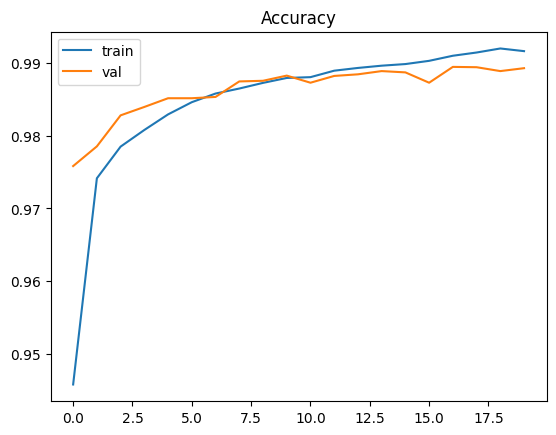

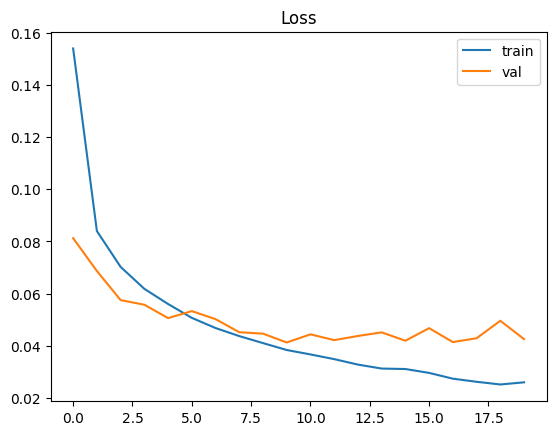

In [50]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

3rd model

In [51]:
label_map = {
    # Normal
    'NSR': 0,

    # Non-dangerous arrhythmia
    'AFIB': 1,
    'AFL': 1,
    'SB': 1,
    'WPW': 1,
    'MII': 1,

    # Dangerous (cardiac arrest risk)
    'VT': 2,
    'VF': 2,
    'VFL': 2
}

In [52]:
import os
import pandas as pd
import numpy as np

base_path = "C:\\Users\\PC\\Desktop\\MIT_2\\archive (1)\\vfdb"  # change this

X = []
y = []

WINDOW = 300

In [82]:
import wfdb
print("RAW SYMBOL:", row['symbol'])
symbol = str(row['symbol']).replace('(', '').strip()
print("PROCESSED SYMBOL:", symbol)

    # break   

RAW SYMBOL: (AFIB
PROCESSED SYMBOL: AFIB


In [83]:
import os
import pandas as pd
import numpy as np

base_path = "C:\\Users\\PC\\Desktop\\MIT_2\\archive (1)\\vfdb" # change this

X = []
y = []

WINDOW = 300

files = [f for f in os.listdir(base_path) if f.endswith("_ekg.csv")]

for file in files:
    record_name = file.replace("_ekg.csv", "")
    
    ecg_path = os.path.join(base_path, record_name + "_ekg.csv")
    ann_path = os.path.join(base_path, record_name + "_annotations.csv")
    
    ecg = pd.read_csv(ecg_path)
    ann = pd.read_csv(ann_path)
    
    signal = ecg['ecg'].values

    print(f"\nProcessing: {record_name}")

    for _, row in ann.iterrows():
        idx = int(row['sample'])
        
        # Clean label
        symbol = str(row['symbol']).replace('(', '').strip()

        # Check label exists
        if symbol not in label_map:
            continue

        # Define window
        start = idx - WINDOW//2
        end   = idx + WINDOW//2

        # Boundary check
        if start < 0 or end > len(signal):
            continue

        segment = signal[start:end]

        # DEBUG (print only first few)
        if len(X) < 5:
            print("Segment length:", len(segment), "| Label:", symbol)

        X.append(segment)
        y.append(label_map[symbol])

print("\nTotal collected samples:", len(X))


Processing: 418
Segment length: 300 | Label: VFL
Segment length: 300 | Label: VFL
Segment length: 300 | Label: VFL
Segment length: 300 | Label: VFL
Segment length: 300 | Label: VFL

Processing: 419

Processing: 420

Processing: 421

Processing: 422

Processing: 423

Processing: 424

Processing: 425

Processing: 426

Processing: 427

Processing: 428

Processing: 429

Processing: 430

Processing: 602

Processing: 605

Processing: 607

Processing: 609

Processing: 610

Processing: 611

Processing: 612

Processing: 614

Processing: 615

Total collected samples: 209


In [84]:
print(type(X))
print(len(X))

if len(X) > 0:
    print(type(X[0]))
    print(len(X[0]))

<class 'list'>
209
<class 'numpy.ndarray'>
300


In [85]:
import wfdb
import numpy as np

data_path = "C:/Users/PC/Desktop/MIT_2/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0/"

records = [str(i) for i in range(100, 235)]

X_mit = []
y_mit = []

WINDOW = 300

# Label mapping
label_map_mit = {
    'N': 0,  # Normal
    'L': 1, 'R': 1, 'A': 1, 'V': 1, 'F': 1  # arrhythmia
}

for record in records:
    try:
        rec = wfdb.rdrecord(data_path + record)
        ann = wfdb.rdann(data_path + record, 'atr')
        
        signal = rec.p_signal[:, 0]  # use lead 0
        
        for i in range(len(ann.sample)):
            symbol = ann.symbol[i]
            
            if symbol not in label_map_mit:
                continue
            
            idx = ann.sample[i]
            
            start = idx - WINDOW//2
            end   = idx + WINDOW//2
            
            if start < 0 or end > len(signal):
                continue
            
            segment = signal[start:end]
            
            X_mit.append(segment)
            y_mit.append(label_map_mit[symbol])
    
        print(f"Processed MIT record {record}")
    
    except:
        continue

X_mit = np.array(X_mit)
y_mit = np.array(y_mit)

# reshape
X_mit = X_mit.reshape(X_mit.shape[0], X_mit.shape[1], 1)

print("MIT-BIH shape:", X_mit.shape)
print("Labels:", np.unique(y_mit, return_counts=True))

Processed MIT record 100
Processed MIT record 101
Processed MIT record 102
Processed MIT record 103
Processed MIT record 104
Processed MIT record 105
Processed MIT record 106
Processed MIT record 107
Processed MIT record 108
Processed MIT record 109
Processed MIT record 111
Processed MIT record 112
Processed MIT record 113
Processed MIT record 114
Processed MIT record 115
Processed MIT record 116
Processed MIT record 117
Processed MIT record 118
Processed MIT record 119
Processed MIT record 121
Processed MIT record 122
Processed MIT record 123
Processed MIT record 124
Processed MIT record 200
Processed MIT record 201
Processed MIT record 202
Processed MIT record 203
Processed MIT record 205
Processed MIT record 207
Processed MIT record 208
Processed MIT record 209
Processed MIT record 210
Processed MIT record 212
Processed MIT record 213
Processed MIT record 214
Processed MIT record 215
Processed MIT record 217
Processed MIT record 219
Processed MIT record 220
Processed MIT record 221


In [86]:
np.save("X_mit.npy", X_mit)
np.save("y_mit.npy", y_mit)

In [87]:
X_vfdb = np.array(X)
y_vfdb = np.array(y)

# Convert ALL VFDB labels → class 2 (dangerous)
y_vfdb[:] = 2

# Reshape
X_vfdb = X_vfdb.reshape(X_vfdb.shape[0], X_vfdb.shape[1], 1)

print("VFDB shape:", X_vfdb.shape)
print("Labels:", np.unique(y_vfdb, return_counts=True))

VFDB shape: (209, 300, 1)
Labels: (array([2]), array([209], dtype=int64))


In [88]:
np.save("X_vfdb.npy", X_vfdb)
np.save("y_vfdb.npy", y_vfdb)

In [89]:
import numpy as np

X_mit = np.load("X_mit.npy")
y_mit = np.load("y_mit.npy")

X_vfdb = np.load("X_vfdb.npy")
y_vfdb = np.load("y_vfdb.npy")

In [90]:
X_total = np.concatenate([X_mit, X_vfdb], axis=0)
y_total = np.concatenate([y_mit, y_vfdb], axis=0)

print("Total shape:", X_total.shape)

Total shape: (101029, 300, 1)


In [91]:
from collections import Counter
print("Class distribution:", Counter(y_total))

Class distribution: Counter({0: 75017, 1: 25803, 2: 209})


In [92]:
from collections import Counter
print("MIT:", Counter(y_mit))
print("VFDB:", Counter(y_vfdb))

MIT: Counter({0: 75017, 1: 25803})
VFDB: Counter({2: 209})


In [93]:
X = []
y = []

In [94]:
from sklearn.utils import resample
from collections import Counter

# Extract dangerous class
X_2 = X_total[y_total == 2]
y_2 = y_total[y_total == 2]

print("Before balancing:", Counter(y_total))

# Upsample class 2
X_2_up, y_2_up = resample(
    X_2, y_2,
    replace=True,
    n_samples=20000,   # important (not too high, not too low)
    random_state=42
)

# Merge back
X_total = np.concatenate([X_total, X_2_up])
y_total = np.concatenate([y_total, y_2_up])

print("After balancing:", Counter(y_total))

Before balancing: Counter({0: 75017, 1: 25803, 2: 209})
After balancing: Counter({0: 75017, 1: 25803, 2: 20209})


In [95]:
from sklearn.utils import shuffle

X_total, y_total = shuffle(X_total, y_total, random_state=42)

In [96]:
np.save("X_final.npy", X_total)
np.save("y_final.npy", y_total)

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_total, y_total,
    test_size=0.2,
    random_state=42,
    stratify=y_total
)

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

cnn_arrhythmia_model = Sequential([
    Conv1D(32, 5, activation='relu', input_shape=(300,1)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(64, 5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

In [99]:
cnn_arrhythmia_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [100]:
history = cnn_arrhythmia_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1513/1513 [==============================] - 6s 4ms/step - loss: 0.1106 - accuracy: 0.9665 - val_loss: 0.0499 - val_accuracy: 0.9867
Epoch 2/10
1513/1513 [==============================] - 6s 4ms/step - loss: 0.0626 - accuracy: 0.9815 - val_loss: 0.0393 - val_accuracy: 0.9883
Epoch 3/10
1513/1513 [==============================] - 6s 4ms/step - loss: 0.0484 - accuracy: 0.9853 - val_loss: 0.0446 - val_accuracy: 0.9844
Epoch 4/10
1513/1513 [==============================] - 5s 3ms/step - loss: 0.0426 - accuracy: 0.9869 - val_loss: 0.0267 - val_accuracy: 0.9923
Epoch 5/10
1513/1513 [==============================] - 8s 5ms/step - loss: 0.0364 - accuracy: 0.9892 - val_loss: 0.0315 - val_accuracy: 0.9926
Epoch 6/10
1513/1513 [==============================] - 9s 6ms/step - loss: 0.0336 - accuracy: 0.9899 - val_loss: 0.0258 - val_accuracy: 0.9933
Epoch 7/10
1513/1513 [==============================] - 7s 5ms/step - loss: 0.0296 - accuracy: 0.9908 - val_loss: 0.0285 - val_accuracy:

In [102]:
loss, acc = cnn_arrhythmia_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

757/757 [==============================] - 1s 2ms/step - loss: 0.0401 - accuracy: 0.9898
Test Accuracy: 0.9897959232330322


In [103]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = cnn_arrhythmia_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred))

757/757 [==============================] - 1s 1ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15003
           1       0.98      0.98      0.98      5161
           2       1.00      0.99      1.00      4042

    accuracy                           0.99     24206
   macro avg       0.99      0.99      0.99     24206
weighted avg       0.99      0.99      0.99     24206



In [104]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (96823, 300, 1)
Test shape: (24206, 300, 1)


In [105]:
# X_orig = np.load("X_mit.npy")
# y_orig = np.load("y_mit.npy")

# X_vfdb = np.load("X_vfdb.npy")
# y_vfdb = np.load("y_vfdb.npy")

# X_all = np.concatenate([X_orig, X_vfdb])
# y_all = np.concatenate([y_orig, y_vfdb])

In [106]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X_all, y_all,
#     test_size=0.2,
#     stratify=y_all,
#     random_state=42
# )

In [107]:
# from sklearn.utils import resample

# X_2 = X_train[y_train == 2]
# y_2 = y_train[y_train == 2]

# X_2_up, y_2_up = resample(
#     X_2, y_2,
#     replace=True,
#     n_samples=20000,
#     random_state=42
# )

# X_train = np.concatenate([X_train, X_2_up])
# y_train = np.concatenate([y_train, y_2_up])

In [108]:
# from sklearn.utils import shuffle
# X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [109]:
def final_decision(ecg_pred, vitals_pred, hr, spo2, rr):

    if ecg_pred == 2:
        return "🚨 Dangerous Arrhythmia"

    if ecg_pred == 1 and vitals_pred == 2:
        return "🚨 High Risk Cardiac Condition"

    if ecg_pred == 1:
        return "⚠️ Cardiac Arrhythmia"

    if spo2 < 90:
        return "🚨 Hypoxia"

    if rr > 25 or rr < 8:
        return "⚠️ Respiratory Distress"

    if vitals_pred == 2:
        return "🚨 Critical Health Condition"

    if vitals_pred == 1:
        return "⚠️ General Health Risk"

    if hr < 50:
        return "⚠️ Bradycardia"

    if hr > 120:
        return "⚠️ Tachycardia"

    return "✅ Normal Condition"

testing

In [110]:
def test_system(ecg_pred, vitals_pred, hr, spo2, rr):
    result = final_decision(ecg_pred, vitals_pred, hr, spo2, rr)
    
    print("ECG:", ecg_pred,
          "| Vitals:", vitals_pred,
          "| HR:", hr,
          "| SpO2:", spo2,
          "| RR:", rr)
    
    print("👉 Result:", result)
    print("-"*50)

In [111]:
# Normal
test_system(0, 0, 72, 98, 16)

# Arrhythmia
test_system(1, 0, 110, 97, 18)

# Dangerous arrhythmia
test_system(2, 1, 140, 95, 22)

# Respiratory distress
test_system(0, 1, 85, 88, 30)

# Critical condition
test_system(1, 2, 130, 85, 35)

ECG: 0 | Vitals: 0 | HR: 72 | SpO2: 98 | RR: 16
👉 Result: ✅ Normal Condition
--------------------------------------------------
ECG: 1 | Vitals: 0 | HR: 110 | SpO2: 97 | RR: 18
👉 Result: ⚠️ Cardiac Arrhythmia
--------------------------------------------------
ECG: 2 | Vitals: 1 | HR: 140 | SpO2: 95 | RR: 22
👉 Result: 🚨 Dangerous Arrhythmia
--------------------------------------------------
ECG: 0 | Vitals: 1 | HR: 85 | SpO2: 88 | RR: 30
👉 Result: 🚨 Hypoxia
--------------------------------------------------
ECG: 1 | Vitals: 2 | HR: 130 | SpO2: 85 | RR: 35
👉 Result: 🚨 High Risk Cardiac Condition
--------------------------------------------------


In [75]:
# for i in range(50):
#     ecg_sample = X_test[i]
    
#     ecg_pred = model.predict(ecg_sample.reshape(1,300,1)).argmax()
    
#     hr_value = float(hr_test[i])
#     spo2 = np.random.randint(90, 100)
#     rr = np.random.randint(12, 30)
    
#     result = final_decision(ecg_pred, 1, hr, spo2, rr)
    
#     print(result)

In [117]:
for i in range(50):
    ecg_sample = X_test[i]

    ecg_pred = cnn_arrhythmia_model.predict(ecg_sample.reshape(1, 300, 1), verbose=0).argmax()

    hr_value = float(hr_test[i])   # real HR from ECG

    vitals_pred = get_vitals_pred(hr_value)   # ✅ calculated, not hardcoded

    result = final_decision(ecg_pred, vitals_pred, hr_value, 98, 16)

    print(f"ECG: {ecg_pred} | HR: {hr_value:.1f} | Vitals: {vitals_pred} | Result: {result}")

ECG: 0 | HR: 64.3 | Vitals: 0 | Result: ✅ Normal Condition
ECG: 2 | HR: 50.8 | Vitals: 1 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 106.9 | Vitals: 1 | Result: ⚠️ Cardiac Arrhythmia
ECG: 2 | HR: 71.8 | Vitals: 0 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 69.5 | Vitals: 0 | Result: ⚠️ Cardiac Arrhythmia
ECG: 2 | HR: 79.4 | Vitals: 0 | Result: 🚨 Dangerous Arrhythmia
ECG: 0 | HR: 94.7 | Vitals: 0 | Result: ✅ Normal Condition
ECG: 0 | HR: 69.7 | Vitals: 0 | Result: ✅ Normal Condition
ECG: 1 | HR: 87.8 | Vitals: 0 | Result: ⚠️ Cardiac Arrhythmia
ECG: 2 | HR: 68.8 | Vitals: 0 | Result: 🚨 Dangerous Arrhythmia
ECG: 2 | HR: 99.5 | Vitals: 0 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 76.3 | Vitals: 0 | Result: ⚠️ Cardiac Arrhythmia
ECG: 0 | HR: 174.8 | Vitals: 2 | Result: 🚨 Critical Health Condition
ECG: 2 | HR: 83.7 | Vitals: 0 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 71.1 | Vitals: 0 | Result: ⚠️ Cardiac Arrhythmia
ECG: 0 | HR: 112.5 | Vitals: 1 | Result: ⚠️ General Health Risk
E

In [118]:
def get_vitals_pred(hr):
    if hr < 50 or hr > 120:
        return 2   # critical
    elif hr < 60 or hr > 100:
        return 1   # warning
    else:
        return 0   # normal

In [122]:
for i in range(50):
    ecg_sample = X_test[i]

    ecg_pred = cnn_arrhythmia_model.predict(ecg_sample.reshape(1,300,1), verbose=0).argmax()

    hr_value = float(hr_test[i])

    vitals_pred = get_vitals_pred(hr_value)
 
    result = final_decision(ecg_pred, vitals_pred, hr_value, 98, 16)

    print("ECG:", ecg_pred, "| HR:", hr_value, "| Result:", result)

ECG: 0 | HR: 64.28571428571428 | Result: ✅ Normal Condition
ECG: 2 | HR: 50.8235294117647 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 106.93069306930693 | Result: ⚠️ Cardiac Arrhythmia
ECG: 2 | HR: 71.76079734219269 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 69.45337620578778 | Result: ⚠️ Cardiac Arrhythmia
ECG: 2 | HR: 79.41176470588235 | Result: 🚨 Dangerous Arrhythmia
ECG: 0 | HR: 94.73684210526316 | Result: ✅ Normal Condition
ECG: 0 | HR: 69.6774193548387 | Result: ✅ Normal Condition
ECG: 1 | HR: 87.80487804878048 | Result: ⚠️ Cardiac Arrhythmia
ECG: 2 | HR: 68.78980891719745 | Result: 🚨 Dangerous Arrhythmia
ECG: 2 | HR: 99.53917050691244 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 76.32508833922262 | Result: ⚠️ Cardiac Arrhythmia
ECG: 0 | HR: 174.77611940298507 | Result: 🚨 Critical Health Condition
ECG: 2 | HR: 83.72093023255813 | Result: 🚨 Dangerous Arrhythmia
ECG: 1 | HR: 71.05263157894737 | Result: ⚠️ Cardiac Arrhythmia
ECG: 0 | HR: 112.5 | Result: ⚠️ General Health Risk


linking this file with next file for comparison

In [123]:
import numpy as np
import joblib
import os

EXPORT_DIR = r"C:\Users\PC\Desktop\MIT_2\comparison_data"
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── Save data splits ──────────────────────────────────────
np.save(os.path.join(EXPORT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(EXPORT_DIR, "X_test.npy"),  X_test)
np.save(os.path.join(EXPORT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(EXPORT_DIR, "y_test.npy"),  y_test)
np.save(os.path.join(EXPORT_DIR, "hr_test.npy"), hr_test)
print("✅ Data splits saved")

# ── Save your trained models ──────────────────────────────
import tensorflow as tf

cnn_arrhythmia_model.save(os.path.join(EXPORT_DIR, "cnn_arrhythmia_model.keras"))
lstm_vitals_model.save(os.path.join(EXPORT_DIR, "lstm_vitals_model.keras"))
print("✅ Keras models saved")

# ── Save sklearn models if needed ────────────────────────
joblib.dump(rf_model, os.path.join(EXPORT_DIR, "rf_model.pkl"))
print("✅ RF model saved")

print("\n📁 Export complete:", EXPORT_DIR)
for f in os.listdir(EXPORT_DIR):
    print("  ", f)

✅ Data splits saved
✅ Keras models saved
✅ RF model saved

📁 Export complete: C:\Users\PC\Desktop\MIT_2\comparison_data
   cnn_arrhythmia_model.keras
   hr_test.npy
   lstm_vitals_model.keras
   rf_model.pkl
   X_test.npy
   X_train.npy
   y_test.npy
   y_train.npy
